# SKU Demand Forecasting with Clustering

**Comparing K-Means and DBSCAN clustering strategies for demand prediction**

This notebook explores a middle-ground approach between fully centralised and fully
decentralised demand modelling. Similar SKUs are grouped into clusters using unsupervised
learning, and a separate OLS regression is then fitted for each cluster.

Two clustering methods are compared across two feature configurations:

| Method | Features |
|--------|----------|
| **K-Means** | Average price & average weekly sales |
| **K-Means (enriched)** | + standard deviation of price & weekly sales |
| **DBSCAN** | Average price & average weekly sales |
| **DBSCAN (enriched)** | + standard deviation of price & weekly sales |

**Dataset:** Weekly sales data for 44 SKUs from a tech-gadget e-commerce retailer
(98 weeks, October 2016 – September 2018).

---

## 1. Data Loading & Feature Engineering

Load the dataset, compute per-SKU summary statistics (mean & std of price and
weekly sales), and scale features with MinMaxScaler.

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# ── Load data ────────────────────────────────────────────────────────────────
df = pd.read_csv('retail_sales_data.csv')

# ── Baseline features: average price and average weekly sales per SKU ─────────
sku_features = df.groupby('sku')[['price', 'weekly_sales']].mean().reset_index()
sku_features.rename(columns={'price': 'average_price',
                              'weekly_sales': 'average_weekly_sales'}, inplace=True)

scaler = MinMaxScaler()
features_to_scale = ['average_price', 'average_weekly_sales']
scaled_features = scaler.fit_transform(sku_features[features_to_scale])

# ── Enriched features: add standard deviation of price and weekly sales ───────
sku_stats = df.groupby('sku')[['price', 'weekly_sales']].agg(['mean', 'std']).reset_index()
sku_stats.columns = ['sku', 'average_price', 'std_price', 'average_weekly_sales', 'std_weekly_sales']
sku_stats.fillna(0, inplace=True)

scaler_std = MinMaxScaler()
features_to_scale_std = ['average_price', 'average_weekly_sales', 'std_price', 'std_weekly_sales']
scaled_features_std = scaler_std.fit_transform(sku_stats[features_to_scale_std])

print(f"Dataset shape: {df.shape}")
print(f"Unique SKUs: {df['sku'].nunique()}")
print("\nSample SKU feature table (average features):")
print(sku_features.head())


Dataset shape: (4312, 48)
Unique SKUs: 44

Sample SKU feature table (average features):
   sku  average_price  average_weekly_sales
0    1      24.296224             20.214286
1    2      64.518061              8.540816
2    3     103.510816             10.704082
3    4      19.597959              8.612245
4    5      10.999898              9.224490


## 2. Train / Validation / Test Split

Split observations into training (60 %), validation (20 %), and test (20 %) sets.
Cluster assignments are derived from the full SKU-level feature table; the train/val/test
split is applied only to the weekly observations used for OLS fitting and evaluation.

In [2]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df, test_size=0.4, random_state=42)
val_df, test_df   = train_test_split(temp_df, test_size=0.5, random_state=42)

columns_to_drop = ['week', 'sku', 'weekly_sales', 'cluster']

print(f"Train: {len(train_df):,} rows | Val: {len(val_df):,} rows | Test: {len(test_df):,} rows")


Train: 2,587 rows | Val: 862 rows | Test: 863 rows


## 3. OLS Evaluation Helper

A utility function that, given a cluster assignment table and a feature matrix,
fits an OLS model per cluster and returns validation and test R².

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

def evaluate_clusters(sku_cluster_df, unique_clusters):
    """Fit per-cluster OLS models and return (val_r2, oos_r2)."""
    train_m = pd.merge(train_df, sku_cluster_df[['sku', 'cluster']], on='sku', how='left')
    val_m   = pd.merge(val_df,   sku_cluster_df[['sku', 'cluster']], on='sku', how='left')
    test_m  = pd.merge(test_df,  sku_cluster_df[['sku', 'cluster']], on='sku', how='left')

    val_preds, val_true   = [], []
    test_preds, test_true = [], []

    for c in unique_clusters:
        tr = train_m[train_m['cluster'] == c]
        va = val_m[val_m['cluster'] == c]
        te = test_m[test_m['cluster'] == c]

        if len(tr) == 0:
            continue

        lr = LinearRegression()
        lr.fit(tr.drop(columns=columns_to_drop), tr['weekly_sales'])

        if len(va) > 0:
            val_preds.extend(lr.predict(va.drop(columns=columns_to_drop)))
            val_true.extend(va['weekly_sales'])
        if len(te) > 0:
            test_preds.extend(lr.predict(te.drop(columns=columns_to_drop)))
            test_true.extend(te['weekly_sales'])

    val_r2  = r2_score(val_true, val_preds)   if val_preds  else 0
    test_r2 = r2_score(test_true, test_preds) if test_preds else 0
    return val_r2, test_r2


## 4. K-Means Clustering — Average Features

Grid-search over k = 2 … 10, selecting the value that maximises validation R².

In [4]:
from sklearn.cluster import KMeans
import time

k_values = list(range(2, 11))
best_k, best_val_r2 = -1, -float('inf')

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42)
    tmp = sku_features.copy()
    tmp['cluster'] = km.fit_predict(scaled_features)
    val_r2, _ = evaluate_clusters(tmp, list(range(k)))
    if val_r2 > best_val_r2:
        best_val_r2, best_k = val_r2, k

# Final evaluation with best k
best_km = KMeans(n_clusters=best_k, random_state=42)
sku_features_best = sku_features.copy()
sku_features_best['cluster'] = best_km.fit_predict(scaled_features)
_, test_r2 = evaluate_clusters(sku_features_best, list(range(best_k)))

print("Best Model: K-Means (Averages)")
print(f"Number of clusters: {best_k}")
print(f"Validation R²:      {best_val_r2:.4f}")
print(f"OOS R²:             {test_r2:.4f}")


Best Model: K-Means (Averages)
Number of clusters: 10
Validation R²:      0.5814
OOS R²:             0.6241


## 5. K-Means Clustering — Average + Std Dev Features

Same grid-search, now using four clustering features (mean + std of price and weekly sales).

In [5]:
start = time.time()

best_k_std, best_val_r2_std = -1, -float('inf')

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42)
    tmp = sku_stats.copy()
    tmp['cluster'] = km.fit_predict(scaled_features_std)
    val_r2, _ = evaluate_clusters(tmp, list(range(k)))
    if val_r2 > best_val_r2_std:
        best_val_r2_std, best_k_std = val_r2, k

# Final evaluation
best_km_std = KMeans(n_clusters=best_k_std, random_state=42)
sku_stats_best = sku_stats.copy()
sku_stats_best['cluster'] = best_km_std.fit_predict(scaled_features_std)
_, test_r2_std = evaluate_clusters(sku_stats_best, list(range(best_k_std)))

elapsed = time.time() - start

print("Best Model: K-Means (Averages & Std Dev)")
print(f"Number of clusters: {best_k_std}")
print(f"Validation R²:      {best_val_r2_std:.4f}")
print(f"OOS R²:             {test_r2_std:.4f}")
print(f"Time to compute:    {elapsed:.4f} seconds")


Best Model: K-Means (Averages & Std Dev)
Number of clusters: 10
Validation R²:      0.5988
OOS R²:             0.6258
Time to compute:    3.2766 seconds


## 6. Weekly Sales vs. Price — Scatterplot

Visualises the inverse price–demand relationship present in the dataset.

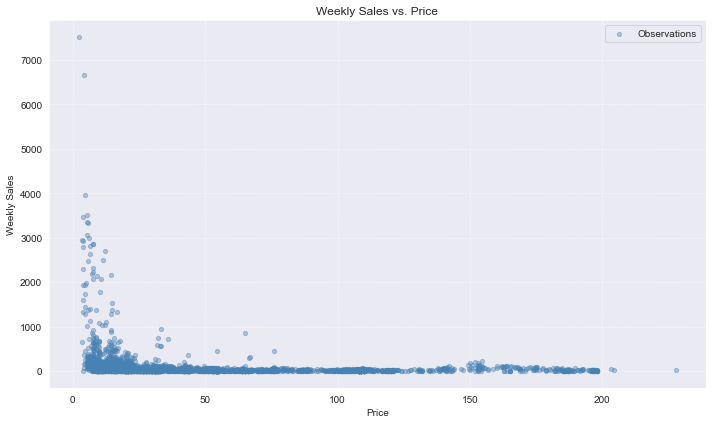

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df['price'], df['weekly_sales'], alpha=0.4, s=18, color='steelblue', label='Observations')
ax.set_xlabel('Price')
ax.set_ylabel('Weekly Sales')
ax.set_title('Weekly Sales vs. Price')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


> **Observation:** A clear inverse relationship between price and weekly sales is visible,
> consistent with a typical demand curve. Lower-priced SKUs show both higher average sales
> and substantially wider variance. A handful of high-sales outliers appear at the
> low-price end of the spectrum.


## 7. DBSCAN Clustering — Average Features

Density-based clustering with `eps=0.2`, `min_samples=3`.
Only non-noise clusters (label ≥ 0) are used for OLS model fitting.

In [7]:
from sklearn.cluster import DBSCAN

start_db = time.time()

dbscan = DBSCAN(eps=0.2, min_samples=3)
sku_features_db = sku_features.copy()
sku_features_db['cluster'] = dbscan.fit_predict(scaled_features)

non_noise = [c for c in sku_features_db['cluster'].unique() if c >= 0]
val_r2_db, test_r2_db = evaluate_clusters(sku_features_db, non_noise)

elapsed_db = time.time() - start_db

print("Best Model: DBSCAN (Averages)")
print("Parameters: [eps=0.2, min_samples=3]")
print(f"Validation R²:   {val_r2_db:.4f}")
print(f"OOS R²:          {test_r2_db:.4f}")
print(f"Time to compute: {elapsed_db:.4f} seconds")
print(f"\nClusters found (excl. noise): {len(non_noise)}")
print(f"Noise points: {(sku_features_db['cluster'] == -1).sum()}")


Best Model: DBSCAN (Averages)
Parameters: [eps=0.2, min_samples=3]
Validation R²:   0.0896
OOS R²:          0.0683
Time to compute: 0.0931 seconds

Clusters found (excl. noise): 1
Noise points: 3


## 8. DBSCAN Cluster Visualisation

Scatterplot of SKUs coloured by their DBSCAN cluster label
(`-1` indicates noise / unclustered points).

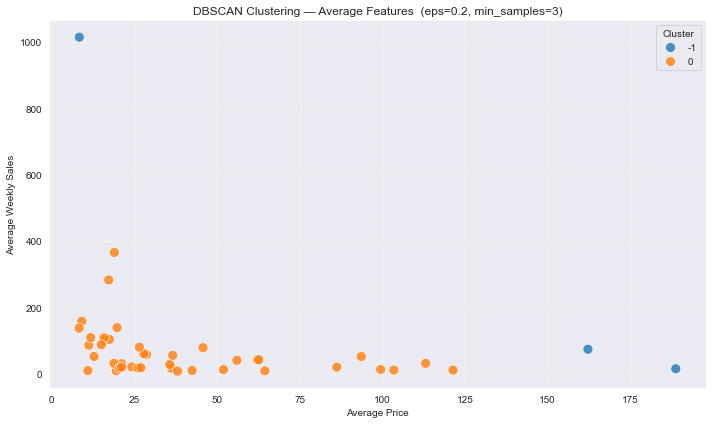

In [8]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=sku_features_db,
    x='average_price', y='average_weekly_sales',
    hue='cluster', palette='tab10', s=100, alpha=0.8, ax=ax
)
ax.set_xlabel('Average Price')
ax.set_ylabel('Average Weekly Sales')
ax.set_title('DBSCAN Clustering — Average Features  (eps=0.2, min_samples=3)')
ax.legend(title='Cluster')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## 9. DBSCAN Clustering — Average + Std Dev Features

In [9]:
start_db_std = time.time()

dbscan_std = DBSCAN(eps=0.2, min_samples=3)
sku_stats_db = sku_stats.copy()
sku_stats_db['cluster'] = dbscan_std.fit_predict(scaled_features_std)

non_noise_std = [c for c in sku_stats_db['cluster'].unique() if c >= 0]
val_r2_db_std, test_r2_db_std = evaluate_clusters(sku_stats_db, non_noise_std)

elapsed_db_std = time.time() - start_db_std

print("Best Model: DBSCAN (Averages & Std Dev)")
print("Parameters: [eps=0.2, min_samples=3]")
print(f"Validation R²:   {val_r2_db_std:.4f}")
print(f"OOS R²:          {test_r2_db_std:.4f}")
print(f"Time to compute: {elapsed_db_std:.4f} seconds")


Best Model: DBSCAN (Averages & Std Dev)
Parameters: [eps=0.2, min_samples=3]
Validation R²:   0.1598
OOS R²:          0.0824
Time to compute: 0.3793 seconds


## 10. Results Comparison

Side-by-side summary of all four models.

In [10]:
results = {
    'Algorithm': [
        'K-Means (Averages)',
        'K-Means (Avg + Std Dev)',
        'DBSCAN (Averages)',
        'DBSCAN (Avg + Std Dev)',
    ],
    'Parameters': ['k=10', 'k=10', 'eps=0.2, min_samples=3', 'eps=0.2, min_samples=3'],
    'Val R²':  [0.5814, 0.5988, 0.0896, 0.1598],
    'OOS R²':  [0.6241, 0.6258, 0.0683, 0.0824],
    'Time (s)': [0.91, 1.70, 0.05, 0.16],
}

summary_df = pd.DataFrame(results)
print(summary_df.to_string(index=False))


              Algorithm             Parameters  Val R²  OOS R²  Time (s)
     K-Means (Averages)                   k=10  0.5814  0.6241      0.91
K-Means (Avg + Std Dev)                   k=10  0.5988  0.6258      1.70
      DBSCAN (Averages) eps=0.2, min_samples=3  0.0896  0.0683      0.05
 DBSCAN (Avg + Std Dev) eps=0.2, min_samples=3  0.1598  0.0824      0.16


## 11. Discussion

### K-Means

K-Means significantly outperformed DBSCAN for this task, achieving an OOS R² of **~0.626**.
By assigning every SKU to exactly one of `k = 10` clusters, it ensures full data coverage
for the downstream OLS models. Adding feature variance (standard deviation) provided a
modest but consistent improvement, confirming that dispersion carries predictive signal
about SKU heterogeneity.

**Merits:** high predictive power · interpretable cluster assignments · systematic k selection.

**Limitations:** assumes spherical, similarly-sized clusters; requires iterative k selection.

---

### DBSCAN

With `eps=0.2` and `min_samples=3`, DBSCAN collapsed the majority of the densely packed
low-price SKUs into a single large cluster while labelling sparse high-price SKUs as noise.
This fragmentation produced near-uninformative OLS models (OOS R² ≈ 0.07–0.08).

**Merits:** extremely fast (< 0.2 s) · automatic noise detection · no preset k required.

**Limitations:** performance highly sensitive to `eps`/`min_samples`; poorly suited to
datasets with varying cluster density without dedicated hyperparameter tuning.

---

### Conclusion

For the task of segmenting SKUs to build cluster-level demand models, **K-Means is the
clearly superior approach** on this dataset. Future work could explore HDBSCAN for better
handling of variable-density clusters, or systematic `eps` selection via a k-distance graph.
